In [ ]:
import sys
import importlib
from pathlib import Path

repo_root = Path.cwd()
src_root = repo_root / 'src'
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

for k in list(sys.modules.keys()):
    if k == 'sigpy' or k.startswith('sigpy.'):
        del sys.modules[k]

from mgrasp_recon import recon_utils
importlib.reload(recon_utils)
from mgrasp_recon.recon_utils import *

from mgrasp_recon import interframe_recon
importlib.reload(interframe_recon)
from mgrasp_recon.interframe_recon import radial_lowres_pca_recon_2d

from mgrasp_recon import vascular_segmentation
importlib.reload(vascular_segmentation)
from mgrasp_recon.vascular_segmentation import *

import sigpy as sp
print('sigpy.__file__ =', sp.__file__)
from sigpy.mri.app import HighDimensionalRecon

import scipy as scp
# print('scipy.__file__ =', scp.__file__)
# print('scipy.__version__ =', scp.__version__)

from scipy.ndimage import gaussian_filter, binary_fill_holes, binary_opening, binary_closing, binary_erosion
from scipy import ndimage as ndi

import argparse
import h5py
import os
import pathlib

import numpy as np
import csv

import re
import glob
import matplotlib.pyplot as plt
import torch
import cupy as cp

from mgrasp_recon import recon_2d
importlib.reload(recon_2d)
from mgrasp_recon.recon_2d import *
from mgrasp_recon import vascular_tic
importlib.reload(vascular_tic)
from mgrasp_recon.vascular_tic import *

from mgrasp_recon import recon_utils as utils
importlib.reload(utils)


> device  <CUDA Device 0>

Reading configurations from: /home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/config_subject.csv
Found 1 configurations to process


Processing DCE
  spokes_per_frame: 46
  slice_idx: 0
  slice_inc: 1
  images_per_slab: 96
> Found 96 slice files in //home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/DCE
> Inferred k-space dimensions from first slice: slices=2, spokes=2220, samples=512, coils=64
> dims: coils=64, spokes=2220, samples=512, N_time=48
  traj shape: (48, 46, 512, 2)

>>> slice 047 | slice48.h5
Loaded raw k-space from //home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/DCE/slice48.h5
  raw shape: (64, 512, 2220, 2), dtype: float64
  ksp_ri shape: (2, 2220, 512, 64)
ksp_coil shape: (2, 2220, 512, 64)
  k1 shape: (64, 2220, 512)
[get_coil] k-space shape: (64, 2220, 512)
[get_coil] base_res: 256
[get_coil] N_coils: 64
[get_coil] t

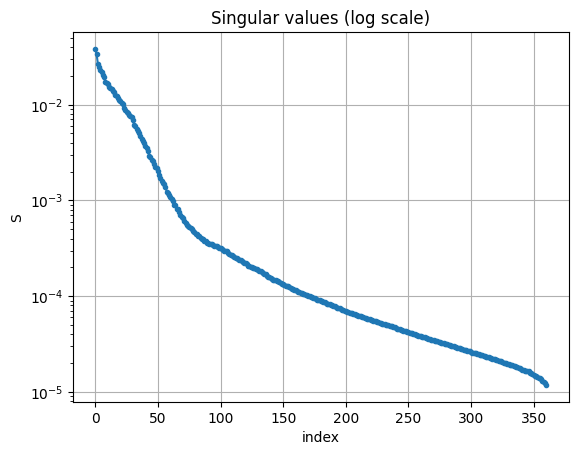

threshold = 0.0007633339
kept = 67 out of 361
Number of kernels kept: 67
before update iteration: 0
current iteration: 1
current iteration: 2
current iteration: 3
current iteration: 4
current iteration: 5
current iteration: 6
current iteration: 7
current iteration: 8
current iteration: 9
current iteration: 10
current iteration: 11
current iteration: 12
current iteration: 13
current iteration: 14
current iteration: 15
current iteration: 16
current iteration: 17
current iteration: 18
current iteration: 19
current iteration: 20
current iteration: 21
current iteration: 22
current iteration: 23
current iteration: 24
current iteration: 25
current iteration: 26
current iteration: 27
current iteration: 28
current iteration: 29
current iteration: 30
current iteration: 31
current iteration: 32
current iteration: 33
current iteration: 34
current iteration: 35
current iteration: 36
current iteration: 37
current iteration: 38
current iteration: 39
current iteration: 40
current iteration: 41
current

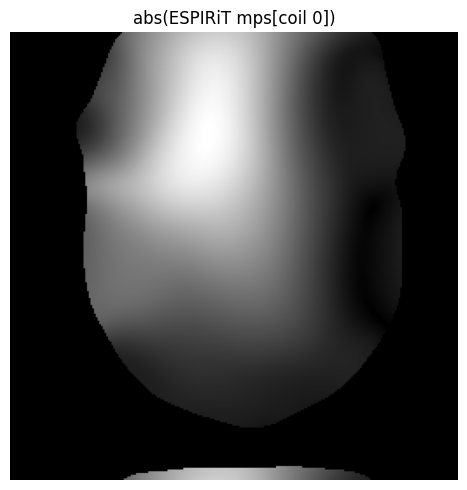

  mps shape: (1, 64, 256, 256)

>>> Testing basis8 | nbasis=8
    lambda = 0.001
Loaded PCA basis from /home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_8.h5 | stored (K,T)=(8, 48) | in-memory (T,K)=(48, 8)
basisoption shape: (48, 9)
ksp_prep shape: (48, 1, 64, 1, 46, 512)
coord_prep shape: (48, 46, 512, 2)
weights shape: (48, 1, 64, 1, 46, 512)
mps shape: (64, 1, 256, 256)
basisoption shape: (48, 9)
>>> ishape :  [9, 1, 1, 1, 256, 256]
>>> B.oshape :  [48, 1, 1, 1, 256, 256]
>>> P.oshape :  [48, 1, 1, 1, 256, 256]
>>> S.oshape :  [48, 1, 64, 1, 256, 256]
>>> F.oshape :  [48, 1, 64, 1, 46, 512]
>>> M.oshape :  [48, 1, 64, 1, 46, 512]
>>> A.oshape :  [48, 1, 64, 1, 46, 512]
F>>> coord shape :  (48, 46, 512, 2)
F>>> input shape :  (48, 1, 64, 1, 256, 256)
F>>> ld_ishape shape :  [1, 64, 1, 256, 256]
F>>> coord shape :  (48, 46, 512, 2)
F>>> input shape :  (48, 1, 64, 1, 256, 256)
F>>> ld_ishape shape :  [1, 64, 1, 256, 256]
F>>> coord shape :  (48, 46, 512, 2)
F>>> input shape :  (48,

In [2]:
# settings: lambda = 0.001, 8 components
class Args:
    base_dir = '//home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/h5slices_wt_acqT/'
    csv_path = '/home/naiqianluan/DCE-MRI/data/DCE_data/20250827-110742-Gross_MeyerA/RAVE_files/config_subject.csv'

    # base_dir = r'E:\nl_2601\data\DCE_data\test'
    # csv_path = r'E:\nl_2601\data\DCE_data\test\config_subject.csv'

args = Args()
subject_id = 'Gross_MeyerA'

device = sp.Device(0 if torch.cuda.is_available() else -1)
print('> device ', device)

# Read configurations from CSV
print(f"\nReading configurations from: {args.csv_path}")
with open(args.csv_path, 'r') as f:
    pass
configs = utils.read_csv_config(args.csv_path)
print(f"Found {len(configs)} configurations to process\n")

# test_var = 'regu_axes_012'

# Loop through each HOP directory
for config in configs:
    
    args.hop_id = config['hop_id']
    # args.spokes_per_frame = config['spokes_per_frame']
    args.spokes_per_frame = 46
    # args.slice_idx = config['slice_idx']
    # args.slice_inc = config['slice_inc']
    args.slice_idx = 0 # process all slices
    args.slice_inc = 1
    args.images_per_slab = config['images_per_slab']
    
    print(f"\n{'='*60}")
    print(f"Processing {args.hop_id}")
    print(f"{'='*60}")
    print(f"  spokes_per_frame: {args.spokes_per_frame}")
    print(f"  slice_idx: {args.slice_idx}")
    print(f"  slice_inc: {args.slice_inc}")
    print(f"  images_per_slab: {args.images_per_slab}")

    hop_dir = os.path.join(args.base_dir, args.hop_id)
    if not os.path.exists(hop_dir):
        raise FileNotFoundError(f"Directory not found: {hop_dir}")
    
    slice_files = utils.list_slice_files(hop_dir)
    N_slices_total = len(slice_files)
    print(f"> Found {N_slices_total} slice files in {hop_dir}")
    N_coils,N_samples,N_spokes,N_slices = utils.infer_kspace_dims(slice_files[0])
    print(f"> Inferred k-space dimensions from first slice: slices={N_slices}, spokes={N_spokes}, samples={N_samples}, coils={N_coils}")
    base_res = N_samples // 2
    N_time = N_spokes // args.spokes_per_frame
    if N_time <= 0:
        raise ValueError(f"N_time={N_time}. Check spokes_per_frame={args.spokes_per_frame} vs N_spokes={N_spokes}")
    
    traj = utils.get_traj(N_spokes=args.spokes_per_frame, N_time=N_time, base_res=base_res, gind=1)
    print(f"> dims: coils={N_coils}, spokes={N_spokes}, samples={N_samples}, N_time={N_time}")
    print(f"  traj shape: {traj.shape}")
    # 
    smax = 0.0
    s = 47 # test on one slice first
    sf = slice_files[s]
    print(f"\n>>> slice {str(s).zfill(3)} | {os.path.basename(sf)}")

    ksp_coil = utils.load_slice_kspace_for_coil(sf)      # (2, spokes, samples, coils)
    print("ksp_coil shape:", ksp_coil.shape)
    ksp_c_for_coil = utils.ri_to_coil_spokes_samples(ksp_coil)
    print("  k1 shape:", ksp_c_for_coil.shape)

    # Compute coil sensitivities once for this slice
    mps = utils.get_coil(ksp_c_for_coil, device=-1,thresh =0.02)
    print('  mps shape:', np.asarray(sp.to_device(mps, sp.cpu_device)).shape)

    # 3. then loop over basis and lambda
    # basis_configs = [
    #     ("basis6", "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_6.h5", 6),
    #     ("basis8", "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_8.h5", 8),
    #     ("basis10", "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_10.h5", 10),
    # ]

    basis_configs = [
         ("basis8", "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_8.h5", 8),
        # ("basis10", "/home/naiqianluan/DCE-MRI/data/test-pro-grasp/fbasis_10.h5", 10),

        # ("basis8", r"E:\nl_2601\data\DCE_data\test\fbasis_8.h5", 8),
    ]

    # lambda_test_val = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2]
    lambda_test_val = [1e-3]
    # voxel_list = [(180, 120), (200, 135)]

    save_dir = "lambda_test_outputs"
    os.makedirs(save_dir, exist_ok=True)

    for basis_name, fbasis_path, nbasis_val in basis_configs:
        print(f"\n>>> Testing {basis_name} | nbasis={nbasis_val}")

        basis_save_dir = os.path.join(save_dir, basis_name)
        os.makedirs(basis_save_dir, exist_ok=True)

        for lambda_test in lambda_test_val:
            lambda_label = f"{lambda_test:.3g}"
            lambda_str = f"{lambda_test:.0e}".replace("-", "m")

            print(f"    lambda = {lambda_label}")

            coeff_maps, img_dyn_cplx, img_dyn_abs, basisoption = run_subspace_recon_2d(
                ksp=ksp_c_for_coil,
                traj=traj,
                mps=mps,
                fbasis_path=fbasis_path,
                spokes_per_frame=args.spokes_per_frame,
                nbasis=nbasis_val,
                cbasis=False,
                add_constant=True,
                lamda=lambda_test,
                regu="TV",
                regu_axes=[-2, -1],
                max_iter=10,
                solver="ADMM",
                use_dcf=True,
                show_pbar=False,
            )

            recon_h5_dir = os.path.join(basis_save_dir, f"recon_h5_lambda_{lambda_str}")
            os.makedirs(recon_h5_dir, exist_ok=True)
            slice_h5_path = os.path.join(
                recon_h5_dir,
                f"{args.hop_id}_slice_{s:03d}_{basis_name}_lambda_{lambda_str}.h5"
            )
            save_slice_h5(
                out_path=slice_h5_path,
                acq_slice=np.asarray(img_dyn_cplx),
                hop_id=args.hop_id,
                spokes_per_frame=args.spokes_per_frame,
                N_time=img_dyn_cplx.shape[0],
                slice_idx=s,
                smax=np.max(img_dyn_abs),
            )
            print(f"    saved slice recon to: {slice_h5_path}")

            #--- testï¼šcheck TIC for two voxles ï¼ˆ1 @ top vessel, 1@ other brain structure)
            # for testing: first try on one slice, visualize the reconstructed dynamic images and TIC curves at some voxels


            # fig = plt.figure(figsize=(12, 4))
            # fig.suptitle(f"{basis_name}, lambda = {lambda_label}", fontsize=14)

            # for i, idx in enumerate([0, img_dyn_abs.shape[0] // 2, img_dyn_abs.shape[0] - 1]):
            #     plt.subplot(1, 3, i + 1)
            #     plt.imshow(img_dyn_abs[idx], cmap="gray")
            #     plt.title(f"Frame {idx}")
            #     plt.axis("off")

            # plt.tight_layout(rect=[0, 0, 1, 0.92])
            # fig.savefig(
            #     os.path.join(basis_save_dir, f"recon_frames_{basis_name}_lambda_{lambda_str}.png"),
            #     dpi=200,
            #     bbox_inches="tight",
            # )
            # plt.show()
            # plt.close(fig)

            # for voxel_coord in voxel_list:
            #     r, c = voxel_coord

            #     fig = plt.figure(figsize=(6, 6))
            #     plt.imshow(img_dyn_abs.mean(axis=0), cmap="gray")
            #     plt.scatter([c], [r], c="red", s=80)
            #     plt.text(c + 2, r - 2, f"({r}, {c})", color="yellow")
            #     plt.title(f"{basis_name}, voxel {voxel_coord}\nlambda = {lambda_label}")
            #     plt.axis("off")
            #     plt.tight_layout()
            #     fig.savefig(
            #         os.path.join(
            #             basis_save_dir,
            #             f"voxel_location_{basis_name}_r{r}_c{c}_lambda_{lambda_str}.png"
            #         ),
            #         dpi=200,
            #         bbox_inches="tight",
            #     )
            #     plt.show()
            #     plt.close(fig)

            #     curve = extract_voxel_tic(img_dyn_abs, voxel_coord, normalize=False)
            #     t = np.arange(len(curve)) * 3.8

            #     fig = plt.figure(figsize=(7, 4))
            #     plt.plot(t, curve, linewidth=2)
            #     plt.xlabel("Time (s)")
            #     plt.ylabel("Intensity")
            #     plt.title(f"{basis_name}, TIC at voxel {voxel_coord}\nlambda = {lambda_label}")
            #     plt.grid(alpha=0.3)
            #     plt.tight_layout()
            #     fig.savefig(
            #         os.path.join(
            #             basis_save_dir,
            #             f"tic_{basis_name}_r{r}_c{c}_lambda_{lambda_str}.png"
            #         ),
            #         dpi=200,
            #         bbox_inches="tight",
            #     )
            #     plt.show()
            #     plt.close(fig)

        
        
        
    

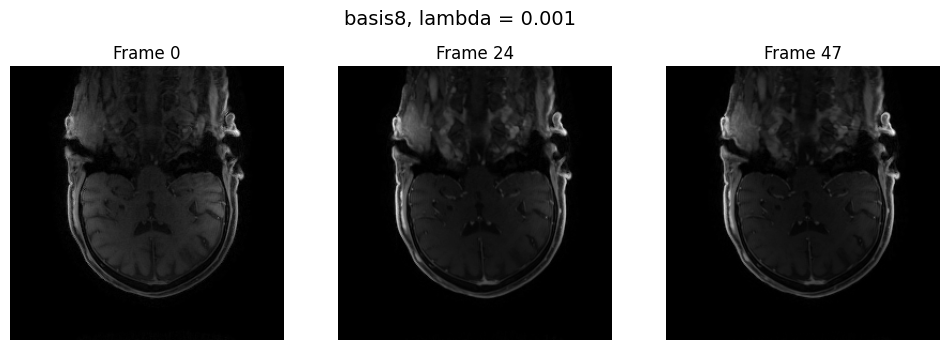

In [3]:
fig = plt.figure(figsize=(12, 4))
fig.suptitle(f"{basis_name}, lambda = {lambda_label}", fontsize=14)

for i, idx in enumerate([0, img_dyn_abs.shape[0] // 2, img_dyn_abs.shape[0] - 1]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img_dyn_abs[idx], cmap="gray")
    plt.title(f"Frame {idx}")
    plt.axis("off")
